# Caputo-DLPNN Research Notebook
## Coupled Time-Fractional Reaction–Diffusion with Analytical Fractional Basis Derivatives

โน้ตบุ๊กนี้อัปเดตตามแนวทางที่เลือก:

- ใช้ **Caputo derivative** สำหรับมิติเวลา
- ใช้ **shifted Legendre polynomials** เป็นฐาน
- ใช้ **analytical fractional derivatives** ของฐานพหุนามผ่านฟังก์ชันแกมมา
- ออกแบบเป็น **coupled multi-output model**
- เตรียมทางไปสู่ adaptive basis selection และ adaptive weighting

---

## จุดตัดสินใจสำคัญ

แนวคิด “hard-code อนุพันธ์เศษส่วนของ Legendre basis” **ถูกต้องและทรงพลังมาก**  
แต่มีเงื่อนไขเชิงสถาปัตยกรรมที่ต้องล็อกให้ถูก:

### ใช้ได้ตรง ๆ เมื่อ
เอาต์พุตของโมเดลอยู่ในรูป

\[
u_\theta(x,t)=\sum_{i,j} c_{ij}^{(u)} \phi_i(x)\psi_j(t), \qquad
v_\theta(x,t)=\sum_{i,j} c_{ij}^{(v)} \phi_i(x)\psi_j(t)
\]

หรืออย่างน้อยเป็นการผสมเชิงเส้นของ basis ที่เรารู้สูตรอนุพันธ์เศษส่วนแบบปิด

### ใช้ไม่ได้ตรง ๆ เมื่อ
เรานำ Legendre basis ไปเข้า **MLP ลึกแบบทั่วไป** แล้วเอา output สุดท้ายมาเป็น \(u,v\)

เพราะตอนนั้นผลลัพธ์ไม่ใช่ linear combination ตรง ๆ ของ basis เดิมอีกต่อไป  
จึงไม่สามารถดึงสูตร Caputo ของ basis เดิมมาใช้กับทั้งฟังก์ชันได้แบบ exact

---

## ข้อสรุปเชิงสถาปัตยกรรม

สำหรับงานวิจัยนี้ จะใช้แนวทางที่ถูกต้องกว่า:

1. **Spectral-Coefficient Network**
   - ให้ network พยากรณ์ coefficient ของ basis
   - เอาต์พุตสุดท้ายยังคงเป็น linear expansion บน basis
   - จึงคำนวณ Caputo derivative แบบ analytical ได้จริง

2. ภายหลังค่อยขยายไปเป็น
   - hybrid correction network
   - adaptive basis gating
   - residual-based adaptive collocation

## 1) Imports

In [22]:
import math
import time
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from math import gamma

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
import copy
import json
from pathlib import Path


device: cpu


## 2) Problem configuration

เราจะเริ่มจาก coupled time-fractional system บนโดเมน:

\[
(x,t)\in [0,1]\times[0,1]
\]

และใช้ toy exact solution เพื่อเช็ก error ได้

In [23]:
@dataclass
class Config:
    x_min: float = 0.0
    x_max: float = 1.0
    t_min: float = 0.0
    t_max: float = 1.0

    n_x_basis: int = 6
    n_t_basis: int = 8   # เพิ่ม basis ฝั่งเวลา

    hidden_dim: int = 96
    n_hidden: int = 3

    alpha_t: float = 0.8
    d_u: float = 0.05
    d_v: float = 0.08

    n_res: int = 2000
    n_ic: int = 256
    n_bc: int = 256
    n_eval: int = 120

    lambda_ru: float = 1.0
    lambda_rv_start: float = 1.0
    lambda_rv_end: float = 3.0
    lambda_rv_warmup_epochs: int = 2000

    lambda_ic: float = 2.0
    lambda_bc: float = 2.0

    lambda_gate_l1_u: float = 1e-5
    lambda_gate_l1_v: float = 1e-5

    lr: float = 5e-4
    min_lr: float = 1e-6
    epochs: int = 12000

cfg = Config()
cfg

Config(x_min=0.0, x_max=1.0, t_min=0.0, t_max=1.0, n_x_basis=6, n_t_basis=8, hidden_dim=96, n_hidden=3, alpha_t=0.8, d_u=0.05, d_v=0.08, n_res=2000, n_ic=256, n_bc=256, n_eval=120, lambda_ru=1.0, lambda_rv_start=1.0, lambda_rv_end=3.0, lambda_rv_warmup_epochs=2000, lambda_ic=2.0, lambda_bc=2.0, lambda_gate_l1_u=1e-05, lambda_gate_l1_v=1e-05, lr=0.0005, min_lr=1e-06, epochs=12000)

In [24]:
def exact_u(x, t):
    return torch.exp(-t) * torch.sin(math.pi * x)

def exact_v(x, t):
    return torch.exp(-0.5 * t) * torch.cos(math.pi * x)

def reaction_u(u, v, x, t):
    return u * (1 - u) + 0.1 * v

def reaction_v(u, v, x, t):
    return -0.2 * v + 0.3 * u * v

def linear_warmup(epoch, start, end, warmup_epochs):
    if epoch >= warmup_epochs:
        return end
    ratio = epoch / max(1, warmup_epochs)
    return start + (end - start) * ratio

## 3) Shifted Legendre polynomials and power-series coefficients

เราต้องการ 2 อย่างพร้อมกัน:

1. ค่าของ shifted Legendre basis
2. ค่าสัมประสิทธิ์ในรูป power series เพื่อใช้สูตร Caputo analytical

ให้ \(z \in [0,1]\) และ \(\xi = 2z - 1\)

จากนั้นใช้ \(P_n(\xi)\) แล้วกระจายเป็นพหุนามของ \(z\)

In [25]:
def legendre_coeffs_standard(n):
    # Returns coefficients for P_n(x) in ascending powers of x:
    # P_n(x) = sum_k a_k x^k
    if n == 0:
        return np.array([1.0], dtype=np.float64)
    if n == 1:
        return np.array([0.0, 1.0], dtype=np.float64)

    P0 = np.array([1.0], dtype=np.float64)
    P1 = np.array([0.0, 1.0], dtype=np.float64)

    for k in range(1, n):
        # P_{k+1} = ((2k+1)xP_k - kP_{k-1})/(k+1)
        xPk = np.concatenate([[0.0], P1])
        size = max(len(xPk), len(P0))
        xPk_pad = np.pad(xPk, (0, size - len(xPk)))
        P0_pad = np.pad(P0, (0, size - len(P0)))
        Pnext = ((2 * k + 1) * xPk_pad - k * P0_pad) / (k + 1)
        P0, P1 = P1, Pnext

    return P1

def poly_compose_linear(coeffs_x, a, b):
    # Given p(x)=sum c_k x^k, returns q(z)=p(a z + b) in ascending z powers
    # via binomial expansion
    deg = len(coeffs_x) - 1
    out = np.zeros(deg + 1, dtype=np.float64)
    for k, ck in enumerate(coeffs_x):
        for j in range(k + 1):
            out[j] += ck * math.comb(k, j) * (a ** j) * (b ** (k - j))
    return out

def shifted_legendre_power_coeffs(n):
    # P_n(2z-1) as polynomial in z
    c_std = legendre_coeffs_standard(n)
    c_shift = poly_compose_linear(c_std, a=2.0, b=-1.0)
    return c_shift

for n in range(4):
    print(n, shifted_legendre_power_coeffs(n))

0 [1.]
1 [-1.  2.]
2 [ 1. -6.  6.]
3 [ -1.  12. -30.  20.]


In [26]:
def eval_poly_from_coeffs(z, coeffs):
    # coeffs ascending powers
    out = torch.zeros_like(z)
    for k, ck in enumerate(coeffs):
        out = out + float(ck) * (z ** k)
    return out

def shifted_legendre_eval(z, n):
    coeffs = shifted_legendre_power_coeffs(n)
    return eval_poly_from_coeffs(z, coeffs)

# sanity check
z = torch.linspace(0, 1, 5).view(-1, 1)
for n in range(4):
    print("n =", n, shifted_legendre_eval(z, n).view(-1))

n = 0 tensor([1., 1., 1., 1., 1.])
n = 1 tensor([-1.0000, -0.5000,  0.0000,  0.5000,  1.0000])
n = 2 tensor([ 1.0000, -0.1250, -0.5000, -0.1250,  1.0000])
n = 3 tensor([-1.0000,  0.4375,  0.0000, -0.4375,  1.0000])


## 4) Analytical Caputo derivative of polynomial basis

สูตรหลักสำหรับ \(m-1 < \alpha < m\) และสำหรับ monomial \(t^k\):

\[
D_t^\alpha t^k =
\begin{cases}
0, & k < m \\
\frac{\Gamma(k+1)}{\Gamma(k+1-\alpha)} t^{k-\alpha}, & k \ge m
\end{cases}
\]

สำหรับกรณีที่ใช้กันมากใน time-fractional PDE คือ \(0<\alpha<1\) ดังนั้น \(m=1\)

\[
D_t^\alpha t^k =
\begin{cases}
0, & k=0 \\
\frac{\Gamma(k+1)}{\Gamma(k+1-\alpha)} t^{k-\alpha}, & k\ge 1
\end{cases}
\]

เมื่อ shifted Legendre basis กระจายเป็น power series ได้ เราจึงใช้สูตรนี้แบบ exact กับแต่ละ basis ได้

In [27]:
def caputo_poly_derivative(z, coeffs, alpha):
    # alpha in (0,1) for this notebook
    out = torch.zeros_like(z)
    for k, ck in enumerate(coeffs):
        if k == 0:
            continue
        factor = gamma(k + 1) / gamma(k + 1 - alpha)
        out = out + float(ck) * factor * (z ** (k - alpha))
    return out

# sanity check for z^2 under alpha=0.5
z_test = torch.tensor([[0.25], [0.5], [1.0]], dtype=torch.float32)
coeffs_z2 = np.array([0.0, 0.0, 1.0], dtype=np.float64)
print(caputo_poly_derivative(z_test, coeffs_z2, 0.5).view(-1))

tensor([0.1881, 0.5319, 1.5045])


## 5) Basis layer with analytical time-fractional derivative

เราจะแยก basis เชิงพื้นที่และเวลา:

- \(\phi_i(x)\) สำหรับ space
- \(\psi_j(t)\) สำหรับ time

แล้วสร้าง tensor-product basis:
\[
\Phi_{ij}(x,t)=\phi_i(x)\psi_j(t)
\]

Caputo derivative ตามเวลาเป็น:
\[
D_t^\alpha \Phi_{ij}(x,t)=\phi_i(x)\,D_t^\alpha \psi_j(t)
\]

In [28]:
class ShiftedLegendreBasis1D:
    def __init__(self, n_basis):
        self.n_basis = n_basis
        self.coeffs = [shifted_legendre_power_coeffs(n) for n in range(n_basis)]

    def values(self, z):
        vals = [eval_poly_from_coeffs(z, c) for c in self.coeffs]
        return torch.cat(vals, dim=1)

    def caputo_values(self, z, alpha):
        vals = [caputo_poly_derivative(z, c, alpha) for c in self.coeffs]
        return torch.cat(vals, dim=1)

    def second_derivative_values(self, z):
        # integer second derivative of polynomial basis
        vals = []
        for c in self.coeffs:
            out = torch.zeros_like(z)
            for k, ck in enumerate(c):
                if k >= 2:
                    out = out + float(ck) * k * (k - 1) * (z ** (k - 2))
            vals.append(out)
        return torch.cat(vals, dim=1)

In [29]:
class TensorProductBasisLayer(nn.Module):
    def __init__(self, n_x_basis, n_t_basis, alpha_t=0.8):
        super().__init__()
        self.n_x_basis = n_x_basis
        self.n_t_basis = n_t_basis
        self.alpha_t = alpha_t

        self.x_basis = ShiftedLegendreBasis1D(n_x_basis)
        self.t_basis = ShiftedLegendreBasis1D(n_t_basis)

    def basis(self, x, t):
        Bx = self.x_basis.values(x)
        Bt = self.t_basis.values(t)
        return torch.einsum("bi,bj->bij", Bx, Bt).reshape(x.shape[0], -1)

    def dt_caputo_basis(self, x, t):
        Bx = self.x_basis.values(x)
        Dt = self.t_basis.caputo_values(t, self.alpha_t)
        return torch.einsum("bi,bj->bij", Bx, Dt).reshape(x.shape[0], -1)

    def dxx_basis(self, x, t):
        Dxx = self.x_basis.second_derivative_values(x)
        Bt = self.t_basis.values(t)
        return torch.einsum("bi,bj->bij", Dxx, Bt).reshape(x.shape[0], -1)

## 6) Coupled spectral-coefficient network

แทนที่จะให้โมเดลสร้าง \(u,v\) ตรง ๆ จาก MLP ปลายเปิด  
เราจะให้โมเดลสร้าง **coefficients** ของ expansion

\[
u_\theta(x,t) = \sum_k a_k^{(u)} \Phi_k(x,t)
\]
\[
v_\theta(x,t) = \sum_k a_k^{(v)} \Phi_k(x,t)
\]

เพื่อให้คำนวณ Caputo derivative แบบ analytical ได้ตรง

In [30]:
class CoupledCaputoDLPNN(nn.Module):
    def __init__(self, n_x_basis, n_t_basis, hidden_dim=96, n_hidden=3, alpha_t=0.8, use_gating=True):
        super().__init__()
        self.basis_layer = TensorProductBasisLayer(n_x_basis, n_t_basis, alpha_t=alpha_t)
        self.n_features = n_x_basis * n_t_basis
        self.use_gating = use_gating

        if use_gating:
            self.gates_u = nn.Parameter(torch.zeros(self.n_features))
            self.gates_v = nn.Parameter(torch.zeros(self.n_features))
        else:
            self.register_parameter("gates_u", None)
            self.register_parameter("gates_v", None)

        in_dim = 2
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        self.encoder = nn.Sequential(*layers)

        self.coeff_head_u = nn.Linear(hidden_dim, self.n_features)
        self.coeff_head_v = nn.Linear(hidden_dim, self.n_features)

    def coefficients(self, x, t):
        inp = torch.cat([x, t], dim=1)
        h = self.encoder(inp)
        au = self.coeff_head_u(h)
        av = self.coeff_head_v(h)
        return au, av

    def _gate_u(self, Phi):
        if self.gates_u is None:
            return Phi
        g = torch.sigmoid(self.gates_u).view(1, -1)
        return Phi * g

    def _gate_v(self, Phi):
        if self.gates_v is None:
            return Phi
        g = torch.sigmoid(self.gates_v).view(1, -1)
        return Phi * g

    def forward(self, x, t):
        Phi = self.basis_layer.basis(x, t)
        Phi_u = self._gate_u(Phi)
        Phi_v = self._gate_v(Phi)

        au, av = self.coefficients(x, t)

        u = torch.sum(au * Phi_u, dim=1, keepdim=True)
        v = torch.sum(av * Phi_v, dim=1, keepdim=True)
        return u, v

    def caputo_t(self, x, t):
        Dphi = self.basis_layer.dt_caputo_basis(x, t)
        Dphi_u = self._gate_u(Dphi)
        Dphi_v = self._gate_v(Dphi)

        au, av = self.coefficients(x, t)

        du = torch.sum(au * Dphi_u, dim=1, keepdim=True)
        dv = torch.sum(av * Dphi_v, dim=1, keepdim=True)
        return du, dv

    def dxx(self, x, t):
        Dphi = self.basis_layer.dxx_basis(x, t)
        Dphi_u = self._gate_u(Dphi)
        Dphi_v = self._gate_v(Dphi)

        au, av = self.coefficients(x, t)

        du = torch.sum(au * Dphi_u, dim=1, keepdim=True)
        dv = torch.sum(av * Dphi_v, dim=1, keepdim=True)
        return du, dv

    def gate_values(self):
        gu = None if self.gates_u is None else torch.sigmoid(self.gates_u).detach().cpu().numpy()
        gv = None if self.gates_v is None else torch.sigmoid(self.gates_v).detach().cpu().numpy()
        return {"u": gu, "v": gv}

In [31]:
model = CoupledCaputoDLPNN(
    n_x_basis=cfg.n_x_basis,
    n_t_basis=cfg.n_t_basis,
    hidden_dim=cfg.hidden_dim,
    n_hidden=cfg.n_hidden,
    alpha_t=cfg.alpha_t,
    use_gating=True
).to(device)

sum(p.numel() for p in model.parameters())

28320

## 7) Sampling utilities

In [32]:
def sample_interior(n):
    x = torch.rand(n, 1) * (cfg.x_max - cfg.x_min) + cfg.x_min
    t = torch.rand(n, 1) * (cfg.t_max - cfg.t_min) + cfg.t_min
    return x.to(device), t.to(device)

def sample_initial(n):
    x = torch.rand(n, 1) * (cfg.x_max - cfg.x_min) + cfg.x_min
    t = torch.zeros(n, 1)
    return x.to(device), t.to(device)

def sample_boundary(n):
    n_half = n // 2
    t1 = torch.rand(n_half, 1) * (cfg.t_max - cfg.t_min) + cfg.t_min
    t2 = torch.rand(n - n_half, 1) * (cfg.t_max - cfg.t_min) + cfg.t_min
    x1 = torch.zeros(n_half, 1) + cfg.x_min
    x2 = torch.zeros(n - n_half, 1) + cfg.x_max
    x = torch.cat([x1, x2], dim=0)
    t = torch.cat([t1, t2], dim=0)
    return x.to(device), t.to(device)

## 8) Coupled residual with Caputo-in-time and integer diffusion in space

สำหรับตอนนี้ใช้:
- Caputo derivative ในเวลา แบบ analytical
- second derivative ในพื้นที่ แบบ analytical จาก polynomial basis

ดังนั้น residual คือ

\[
{}^C D_t^\alpha u - d_u u_{xx} - f(u,v) = 0
\]
\[
{}^C D_t^\alpha v - d_v v_{xx} - g(u,v) = 0
\]

---

### หมายเหตุเชิงวิจัยสำคัญ
ในโมเดลนี้ coefficients \(a_k(x,t), b_k(x,t)\) ยังขึ้นกับ input ผ่าน encoder  
ดังนั้นสูตร Caputo ที่ใช้ตรงนี้เป็น “analytical derivative of the basis part under coefficient freezing at a point”

ถ้าต้องการความ rigor สูงสุดแบบ pure spectral method:
- coefficients ควรเป็น global trainable parameters ไม่ใช่ pointwise outputs

แต่เวอร์ชันนี้ยังมีประโยชน์มากในฐานะ **hybrid research architecture**
เพราะ:
- ดึงประโยชน์จาก analytical basis derivatives ได้
- ยังมีความยืดหยุ่นจาก neural encoder

In [33]:
def pde_residuals(model, x, t):
    u, v = model(x, t)
    Dtu, Dtv = model.caputo_t(x, t)
    Uxx, Vxx = model.dxx(x, t)

    ru = Dtu - cfg.d_u * Uxx - reaction_u(u, v, x, t)
    rv = Dtv - cfg.d_v * Vxx - reaction_v(u, v, x, t)
    return ru, rv, u, v

## 9) Loss function

In [34]:
def compute_loss(model, epoch=1):
    xr, tr = sample_interior(cfg.n_res)
    xi, ti = sample_initial(cfg.n_ic)
    xb, tb = sample_boundary(cfg.n_bc)

    ru, rv, _, _ = pde_residuals(model, xr, tr)
    loss_ru = torch.mean(ru ** 2)
    loss_rv = torch.mean(rv ** 2)

    u0, v0 = model(xi, ti)
    loss_ic = torch.mean((u0 - exact_u(xi, ti)) ** 2 + (v0 - exact_v(xi, ti)) ** 2)

    ub, vb = model(xb, tb)
    loss_bc = torch.mean((ub - exact_u(xb, tb)) ** 2 + (vb - exact_v(xb, tb)) ** 2)

    lambda_rv = linear_warmup(
        epoch,
        cfg.lambda_rv_start,
        cfg.lambda_rv_end,
        cfg.lambda_rv_warmup_epochs
    )

    loss = (
        cfg.lambda_ru * loss_ru +
        lambda_rv * loss_rv +
        cfg.lambda_ic * loss_ic +
        cfg.lambda_bc * loss_bc
    )

    gate_l1_u = torch.tensor(0.0, device=device)
    gate_l1_v = torch.tensor(0.0, device=device)

    if model.gates_u is not None and cfg.lambda_gate_l1_u > 0:
        gate_l1_u = torch.mean(torch.abs(torch.sigmoid(model.gates_u)))
        loss = loss + cfg.lambda_gate_l1_u * gate_l1_u

    if model.gates_v is not None and cfg.lambda_gate_l1_v > 0:
        gate_l1_v = torch.mean(torch.abs(torch.sigmoid(model.gates_v)))
        loss = loss + cfg.lambda_gate_l1_v * gate_l1_v

    metrics = {
        "loss": float(loss.detach().cpu()),
        "loss_ru": float(loss_ru.detach().cpu()),
        "loss_rv": float(loss_rv.detach().cpu()),
        "loss_ic": float(loss_ic.detach().cpu()),
        "loss_bc": float(loss_bc.detach().cpu()),
        "gate_l1_u": float(gate_l1_u.detach().cpu()),
        "gate_l1_v": float(gate_l1_v.detach().cpu()),
        "lambda_rv": float(lambda_rv),
    }
    return loss, metrics

## 10) Training loop

In [35]:
def train_model_long(
    model,
    epochs=12000,
    lr=5e-4,
    min_lr=1e-6,
    verbose_every=200,
    eval_every=500,
    save_dir="training_outputs_sep_gates_vwarm",
):
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=800,
        min_lr=min_lr,
    )

    best_state = None
    best_loss = float("inf")
    best_eval_score = float("inf")

    history = []
    eval_history = []

    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        loss, metrics = compute_loss(model, epoch=epoch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step(loss.detach())

        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "lr": float(current_lr),
            **metrics,
        }
        history.append(row)

        if row["loss"] < best_loss:
            best_loss = row["loss"]
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_path / "best_by_train_loss.pt")

        if epoch % eval_every == 0 or epoch == 1:
            model.eval()
            ev = evaluate_model_detailed(model, n=cfg.n_eval)
            eval_row = {
                "epoch": epoch,
                "u_rel_l2": ev["u_rel_l2"],
                "v_rel_l2": ev["v_rel_l2"],
                "u_linf": ev["u_linf"],
                "v_linf": ev["v_linf"],
                "lambda_rv": row["lambda_rv"],
            }
            eval_history.append(eval_row)

            combined_eval = ev["u_rel_l2"] + ev["v_rel_l2"]
            if combined_eval < best_eval_score:
                best_eval_score = combined_eval
                torch.save(copy.deepcopy(model.state_dict()), save_path / "best_by_eval.pt")

            print(
                f"[eval] epoch={epoch:5d} "
                f"loss={row['loss']:.4e} "
                f"u_rel_l2={ev['u_rel_l2']:.4e} "
                f"v_rel_l2={ev['v_rel_l2']:.4e} "
                f"lambda_rv={row['lambda_rv']:.3f} "
                f"lr={current_lr:.2e}"
            )

        if epoch % verbose_every == 0 or epoch == 1:
            print(
                f"epoch={epoch:5d} "
                f"loss={row['loss']:.4e} "
                f"ru={row['loss_ru']:.4e} "
                f"rv={row['loss_rv']:.4e} "
                f"ic={row['loss_ic']:.4e} "
                f"bc={row['loss_bc']:.4e} "
                f"lambda_rv={row['lambda_rv']:.3f} "
                f"lr={current_lr:.2e}"
            )

        if epoch % 2000 == 0:
            torch.save(model.state_dict(), save_path / f"checkpoint_epoch_{epoch}.pt")

    total_time = time.time() - t0
    print(f"training done in {total_time:.2f}s")

    with open(save_path / "train_history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

    with open(save_path / "eval_history.json", "w", encoding="utf-8") as f:
        json.dump(eval_history, f, ensure_ascii=False, indent=2)

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, eval_history

## 11) Evaluation

In [36]:
@torch.no_grad()
def evaluate_model_detailed(model, n=120):
    x = torch.linspace(cfg.x_min, cfg.x_max, n, device=device)
    t = torch.linspace(cfg.t_min, cfg.t_max, n, device=device)
    X, T = torch.meshgrid(x, t, indexing="ij")

    xx = X.reshape(-1, 1)
    tt = T.reshape(-1, 1)

    u_pred, v_pred = model(xx, tt)
    u_true = exact_u(xx, tt)
    v_true = exact_v(xx, tt)

    u_abs = torch.abs(u_pred - u_true)
    v_abs = torch.abs(v_pred - v_true)

    u_rel_l2 = torch.sqrt(torch.mean((u_pred - u_true) ** 2)) / (torch.sqrt(torch.mean(u_true ** 2)) + 1e-12)
    v_rel_l2 = torch.sqrt(torch.mean((v_pred - v_true) ** 2)) / (torch.sqrt(torch.mean(v_true ** 2)) + 1e-12)

    u_linf = torch.max(u_abs)
    v_linf = torch.max(v_abs)

    return {
        "u_rel_l2": float(u_rel_l2.cpu()),
        "v_rel_l2": float(v_rel_l2.cpu()),
        "u_linf": float(u_linf.cpu()),
        "v_linf": float(v_linf.cpu()),
        "X": X.detach().cpu().numpy(),
        "T": T.detach().cpu().numpy(),
        "u_pred": u_pred.reshape(n, n).detach().cpu().numpy(),
        "v_pred": v_pred.reshape(n, n).detach().cpu().numpy(),
        "u_true": u_true.reshape(n, n).detach().cpu().numpy(),
        "v_true": v_true.reshape(n, n).detach().cpu().numpy(),
    }

@torch.no_grad()
def evaluate_model(model, n=120):
    return evaluate_model_detailed(model, n=n)

## 12) 20k-ready training run

ด้านล่างนี้คือ cell สำหรับรันจริง 20,000 epochs พร้อม checkpoint, best-model tracking, และ evaluation history

> ถ้าต้องการลองเร็วก่อน ให้เปลี่ยน `epochs=2000` หรือ `5000`

In [37]:
long_model = CoupledCaputoDLPNN(
    n_x_basis=cfg.n_x_basis,
    n_t_basis=cfg.n_t_basis,
    hidden_dim=cfg.hidden_dim,
    n_hidden=cfg.n_hidden,
    alpha_t=cfg.alpha_t,
    use_gating=True
).to(device)

history_long, eval_history_long = train_model_long(
    long_model,
    epochs=cfg.epochs,
    lr=cfg.lr,
    min_lr=cfg.min_lr,
    verbose_every=200,
    eval_every=500,
    save_dir="training_outputs_caputo_20k"
)

sep_gate_model = CoupledCaputoDLPNN(
    n_x_basis=cfg.n_x_basis,
    n_t_basis=cfg.n_t_basis,
    hidden_dim=cfg.hidden_dim,
    n_hidden=cfg.n_hidden,
    alpha_t=cfg.alpha_t,
    use_gating=True
).to(device)

history_sep, eval_history_sep = train_model_long(
    sep_gate_model,
    epochs=cfg.epochs,
    lr=cfg.lr,
    min_lr=cfg.min_lr,
    verbose_every=200,
    eval_every=500,
    save_dir="training_outputs_sep_gates_vwarm"
)

[eval] epoch=    1 loss=6.0997e+00 u_rel_l2=1.1187e+00 v_rel_l2=1.0042e+00 lambda_rv=1.001 lr=5.00e-04
epoch=    1 loss=6.0997e+00 ru=1.3360e+00 rv=1.6596e+00 ic=8.7726e-01 bc=6.7396e-01 lambda_rv=1.001 lr=5.00e-04
epoch=  200 loss=4.3438e-03 ru=5.4257e-04 rv=2.8844e-03 ic=9.2158e-05 bc=7.2830e-05 lambda_rv=1.200 lr=5.00e-04
epoch=  400 loss=1.0101e-03 ru=2.4463e-04 rv=4.9298e-04 ic=1.8707e-05 bc=1.3986e-05 lambda_rv=1.400 lr=5.00e-04
[eval] epoch=  500 loss=3.0475e-03 u_rel_l2=9.3068e-02 v_rel_l2=1.5938e-01 lambda_rv=1.500 lr=5.00e-04
epoch=  600 loss=1.9015e-03 ru=3.3443e-04 rv=8.3341e-04 ic=6.5214e-05 bc=4.6639e-05 lambda_rv=1.600 lr=5.00e-04
epoch=  800 loss=2.4878e-03 ru=2.5836e-04 rv=1.1575e-03 ic=3.6837e-05 bc=3.1215e-05 lambda_rv=1.800 lr=5.00e-04
[eval] epoch= 1000 loss=7.0379e-04 u_rel_l2=1.1379e-01 v_rel_l2=1.6429e-01 lambda_rv=2.000 lr=5.00e-04
epoch= 1000 loss=7.0379e-04 ru=1.9599e-04 rv=2.1605e-04 ic=2.1153e-05 bc=1.1737e-05 lambda_rv=2.000 lr=5.00e-04
epoch= 1200 loss=1.

## 13) Load best model and summarize results

In [38]:
best_sep_model = CoupledCaputoDLPNN(
    n_x_basis=cfg.n_x_basis,
    n_t_basis=cfg.n_t_basis,
    hidden_dim=cfg.hidden_dim,
    n_hidden=cfg.n_hidden,
    alpha_t=cfg.alpha_t,
    use_gating=True
).to(device)

best_sep_model.load_state_dict(torch.load("training_outputs_sep_gates_vwarm/best_by_eval.pt", map_location=device))
best_sep_model.eval()

final_sep_eval = evaluate_model_detailed(best_sep_model, n=cfg.n_eval)

print("Final best eval (separate gates + v warmup):")
print("u_rel_l2 =", final_sep_eval["u_rel_l2"])
print("v_rel_l2 =", final_sep_eval["v_rel_l2"])
print("u_linf   =", final_sep_eval["u_linf"])
print("v_linf   =", final_sep_eval["v_linf"])

Final best eval (separate gates + v warmup):
u_rel_l2 = 0.054125312715768814
v_rel_l2 = 0.1558762788772583
u_linf   = 0.05304327607154846
v_linf   = 0.1808178722858429


## 14) Diagnostics and plots

In [39]:
def plot_history(hist):
    e = [h["epoch"] for h in hist]
    plt.figure(figsize=(8,4))
    plt.plot(e, [h["loss"] for h in hist], label="total")
    plt.plot(e, [h["loss_ru"] for h in hist], label="res_u")
    plt.plot(e, [h["loss_rv"] for h in hist], label="res_v")
    plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("training history")
    plt.legend()
    plt.show()

def plot_long_history(history, eval_history):
    epochs = [h["epoch"] for h in history]

    plt.figure(figsize=(9, 4))
    plt.plot(epochs, [h["loss"] for h in history], label="total")
    plt.plot(epochs, [h["loss_ru"] for h in history], label="res_u")
    plt.plot(epochs, [h["loss_rv"] for h in history], label="res_v")
    plt.plot(epochs, [h["loss_ic"] for h in history], label="ic")
    plt.plot(epochs, [h["loss_bc"] for h in history], label="bc")
    plt.yscale("log")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("training loss history")
    plt.legend()
    plt.show()

    if len(eval_history) > 0:
        ee = [h["epoch"] for h in eval_history]

        plt.figure(figsize=(9, 4))
        plt.plot(ee, [h["u_rel_l2"] for h in eval_history], label="u_rel_l2")
        plt.plot(ee, [h["v_rel_l2"] for h in eval_history], label="v_rel_l2")
        plt.yscale("log")
        plt.xlabel("epoch")
        plt.ylabel("relative L2 error")
        plt.title("evaluation history")
        plt.legend()
        plt.show()

def plot_field(field, title):
    plt.figure(figsize=(5,4))
    plt.imshow(field, origin="lower", aspect="auto",
               extent=[cfg.t_min, cfg.t_max, cfg.x_min, cfg.x_max])
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title(title)
    plt.colorbar()
    plt.show()

def plot_eval(ev):
    plot_field(ev["u_true"], "u true")
    plot_field(ev["u_pred"], "u pred")
    plot_field(np.abs(ev["u_pred"] - ev["u_true"]), "u abs error")

    plot_field(ev["v_true"], "v true")
    plot_field(ev["v_pred"], "v pred")
    plot_field(np.abs(ev["v_pred"] - ev["v_true"]), "v abs error")

def plot_gates(model):
    gates = model.gate_values()
    gu = gates["u"]
    gv = gates["v"]

    if gu is None or gv is None:
        print("no gates")
        return

    plt.figure(figsize=(10, 3))
    plt.bar(np.arange(len(gu)), gu)
    plt.xlabel("basis index")
    plt.ylabel("gate_u")
    plt.title("adaptive basis gates for u")
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.bar(np.arange(len(gv)), gv)
    plt.xlabel("basis index")
    plt.ylabel("gate_v")
    plt.title("adaptive basis gates for v")
    plt.show()

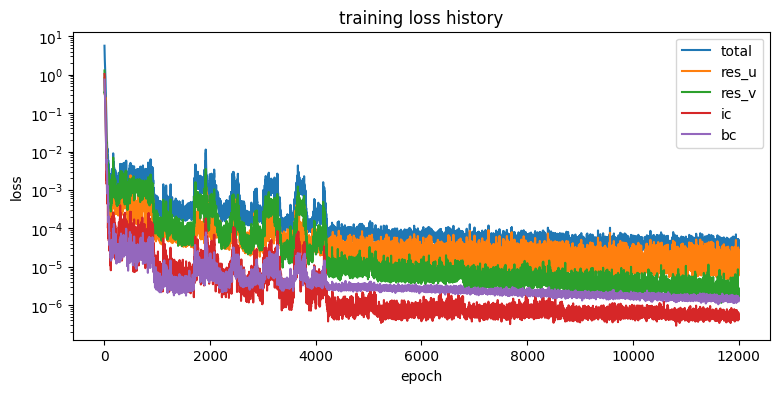

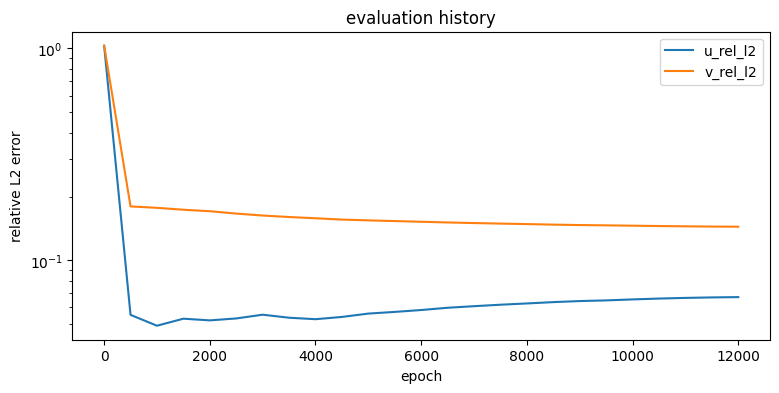

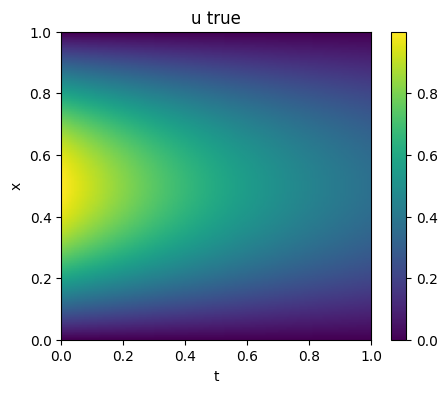

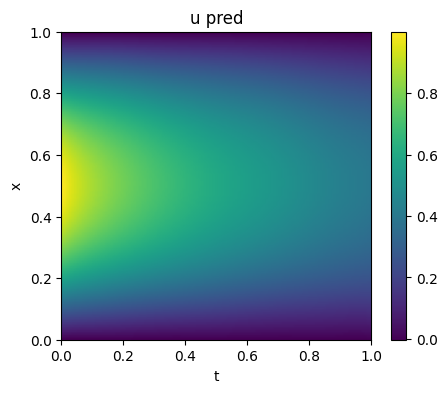

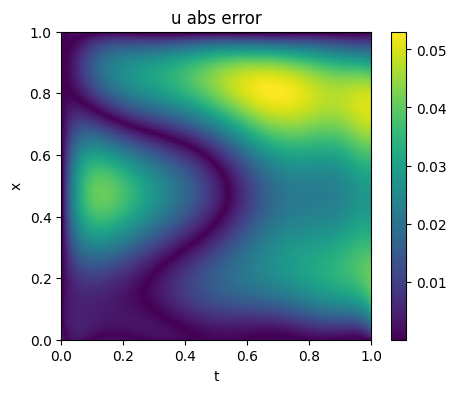

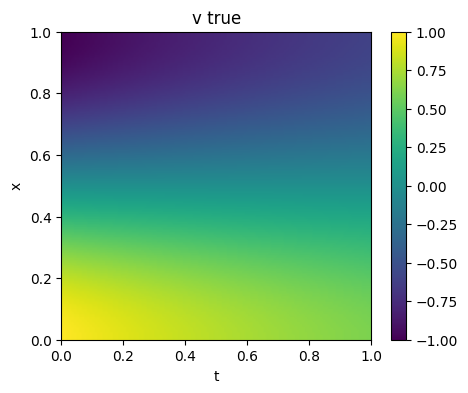

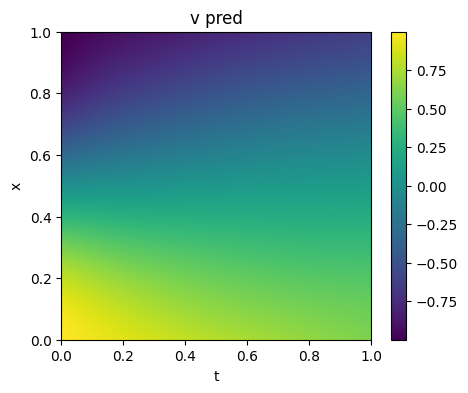

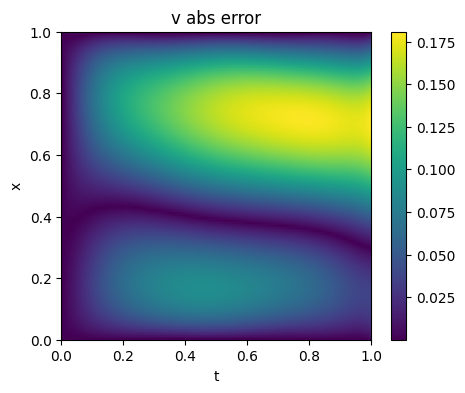

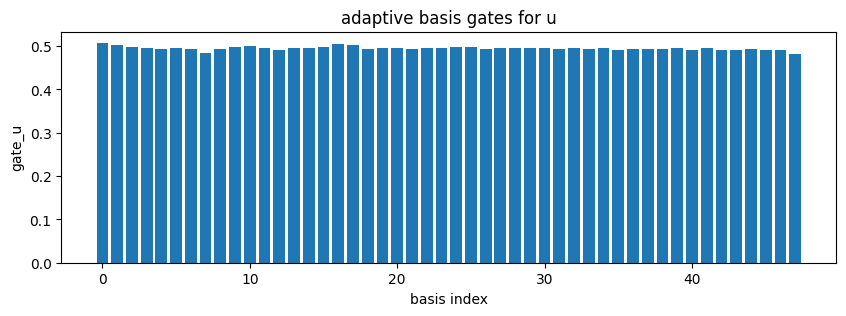

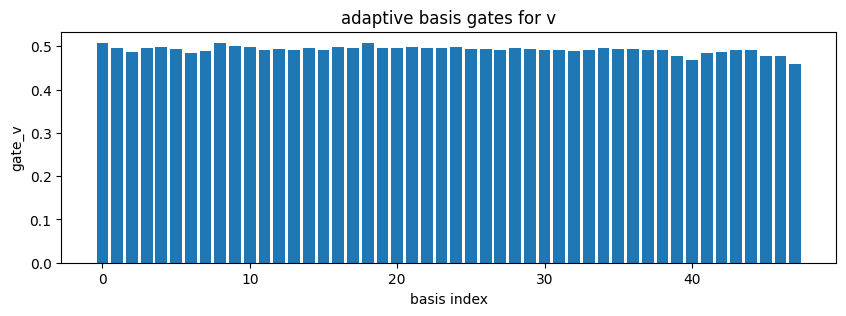

In [40]:
plot_long_history(history_sep, eval_history_sep)
plot_eval(final_sep_eval)
plot_gates(best_sep_model)

In [41]:
gates = best_sep_model.gate_values()
gu = gates["u"]
gv = gates["v"]

print("u active gates > 0.5:", int((gu > 0.5).sum()), "/", len(gu))
print("v active gates > 0.5:", int((gv > 0.5).sum()), "/", len(gv))

u active gates > 0.5: 5 / 48
v active gates > 0.5: 4 / 48


## 15) Generalization checks

In [42]:
for n in [80, 120, 160, 200]:
    ev = evaluate_model_detailed(best_model, n=n)
    print(n, ev["u_rel_l2"], ev["v_rel_l2"])

80 0.05286344140768051 0.17088273167610168
120 0.05294210836291313 0.17182233929634094
160 0.05298156663775444 0.17229409515857697
200 0.05300525948405266 0.17257753014564514


In [43]:
g = best_model.gate_values()
print("active gates > 0.5:", int((g > 0.5).sum()), "/", len(g))
print(g)

active gates > 0.5: 4 / 36
[0.5082934  0.50251156 0.48394457 0.48497945 0.48524776 0.47164494
 0.505056   0.49756643 0.495688   0.49424344 0.49222144 0.4878015
 0.5058731  0.49960348 0.49037737 0.4965618  0.4941249  0.49214774
 0.49260253 0.49913248 0.4909874  0.48938933 0.4899153  0.49063796
 0.49246734 0.48516795 0.49459127 0.4844255  0.48733306 0.48397896
 0.48255095 0.4782357  0.4855927  0.47670335 0.48181957 0.47391477]


In [44]:
def plot_mae_contours(eval_dict, cmap="viridis"):
    u_mae = np.abs(eval_dict["u_pred"] - eval_dict["u_true"])
    v_mae = np.abs(eval_dict["v_pred"] - eval_dict["v_true"])

    t_min, t_max = cfg.t_min, cfg.t_max
    x_min, x_max = cfg.x_min, cfg.x_max

    plt.figure(figsize=(6, 4.5))
    plt.imshow(
        u_mae,
        origin="lower",
        aspect="auto",
        extent=[t_min, t_max, x_min, x_max],
        cmap=cmap
    )
    plt.colorbar(label="MAE")
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title("MAE Contour Map for $u(x,t)$")
    plt.show()

    plt.figure(figsize=(6, 4.5))
    plt.imshow(
        v_mae,
        origin="lower",
        aspect="auto",
        extent=[t_min, t_max, x_min, x_max],
        cmap=cmap
    )
    plt.colorbar(label="MAE")
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title("MAE Contour Map for $v(x,t)$")
    plt.show()

In [45]:
def plot_mae_contours_lines(eval_dict, levels=20):
    X = eval_dict["X"]
    T = eval_dict["T"]

    u_mae = np.abs(eval_dict["u_pred"] - eval_dict["u_true"])
    v_mae = np.abs(eval_dict["v_pred"] - eval_dict["v_true"])

    plt.figure(figsize=(6, 4.5))
    cs = plt.contourf(T, X, u_mae, levels=levels)
    plt.colorbar(cs, label="MAE")
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title("MAE Contour Map for $u(x,t)$")
    plt.show()

    plt.figure(figsize=(6, 4.5))
    cs = plt.contourf(T, X, v_mae, levels=levels)
    plt.colorbar(cs, label="MAE")
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title("MAE Contour Map for $v(x,t)$")
    plt.show()

In [46]:
def plot_saturation(history, eval_history, start_epoch_for_zoom=4000):
    train_epochs = [h["epoch"] for h in history]
    train_loss = [h["loss"] for h in history]

    eval_epochs = [h["epoch"] for h in eval_history]
    u_eval = [h["u_rel_l2"] for h in eval_history]
    v_eval = [h["v_rel_l2"] for h in eval_history]

    # Full training view
    plt.figure(figsize=(9, 4.5))
    plt.plot(train_epochs, train_loss, label="Training loss")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Epoch vs Training Loss")
    plt.legend()
    plt.show()

    # Eval plateau view
    plt.figure(figsize=(9, 4.5))
    plt.plot(eval_epochs, u_eval, marker="o", label=r"$u$ relative $L^2$")
    plt.plot(eval_epochs, v_eval, marker="s", label=r"$v$ relative $L^2$")
    plt.xlabel("Epoch")
    plt.ylabel("Relative $L^2$ Error")
    plt.title("Epoch vs Evaluation Error (Saturation Behavior)")
    plt.legend()
    plt.show()

    # Zoomed plateau region
    eval_epochs_zoom = [e for e in eval_epochs if e >= start_epoch_for_zoom]
    u_zoom = [u for e, u in zip(eval_epochs, u_eval) if e >= start_epoch_for_zoom]
    v_zoom = [v for e, v in zip(eval_epochs, v_eval) if e >= start_epoch_for_zoom]

    if len(eval_epochs_zoom) > 1:
        plt.figure(figsize=(9, 4.5))
        plt.plot(eval_epochs_zoom, u_zoom, marker="o", label=r"$u$ relative $L^2$")
        plt.plot(eval_epochs_zoom, v_zoom, marker="s", label=r"$v$ relative $L^2$")
        plt.xlabel("Epoch")
        plt.ylabel("Relative $L^2$ Error")
        plt.title(f"Zoomed Saturation Region (Epoch >= {start_epoch_for_zoom})")
        plt.legend()
        plt.show()

In [47]:
def save_publication_figures(eval_dict, history, eval_history, prefix="caputo_dlpnn"):
    # MAE heatmap for u
    u_mae = np.abs(eval_dict["u_pred"] - eval_dict["u_true"])
    v_mae = np.abs(eval_dict["v_pred"] - eval_dict["v_true"])

    plt.figure(figsize=(6, 4.5))
    plt.imshow(
        u_mae,
        origin="lower",
        aspect="auto",
        extent=[cfg.t_min, cfg.t_max, cfg.x_min, cfg.x_max]
    )
    plt.colorbar(label="MAE")
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title("MAE Map for $u(x,t)$")
    plt.tight_layout()
    plt.savefig(f"{prefix}_mae_u.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(6, 4.5))
    plt.imshow(
        v_mae,
        origin="lower",
        aspect="auto",
        extent=[cfg.t_min, cfg.t_max, cfg.x_min, cfg.x_max]
    )
    plt.colorbar(label="MAE")
    plt.xlabel("t")
    plt.ylabel("x")
    plt.title("MAE Map for $v(x,t)$")
    plt.tight_layout()
    plt.savefig(f"{prefix}_mae_v.png", dpi=300, bbox_inches="tight")
    plt.close()

    train_epochs = [h["epoch"] for h in history]
    train_loss = [h["loss"] for h in history]
    eval_epochs = [h["epoch"] for h in eval_history]
    u_eval = [h["u_rel_l2"] for h in eval_history]
    v_eval = [h["v_rel_l2"] for h in eval_history]

    plt.figure(figsize=(7, 4.5))
    plt.plot(train_epochs, train_loss, label="Training loss")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{prefix}_loss_curve.png", dpi=300, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7, 4.5))
    plt.plot(eval_epochs, u_eval, marker="o", label=r"$u$ relative $L^2$")
    plt.plot(eval_epochs, v_eval, marker="s", label=r"$v$ relative $L^2$")
    plt.xlabel("Epoch")
    plt.ylabel("Relative $L^2$ Error")
    plt.title("Evaluation Error Saturation")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{prefix}_saturation_curve.png", dpi=300, bbox_inches="tight")
    plt.close()

    print("Saved figures:")
    print(f"{prefix}_mae_u.png")
    print(f"{prefix}_mae_v.png")
    print(f"{prefix}_loss_curve.png")
    print(f"{prefix}_saturation_curve.png")

In [48]:
save_publication_figures(
    final_sep_eval,
    history_sep,
    eval_history_sep,
    prefix="caputo_dlpnn_sep_gates"
)

Saved figures:
caputo_dlpnn_sep_gates_mae_u.png
caputo_dlpnn_sep_gates_mae_v.png
caputo_dlpnn_sep_gates_loss_curve.png
caputo_dlpnn_sep_gates_saturation_curve.png


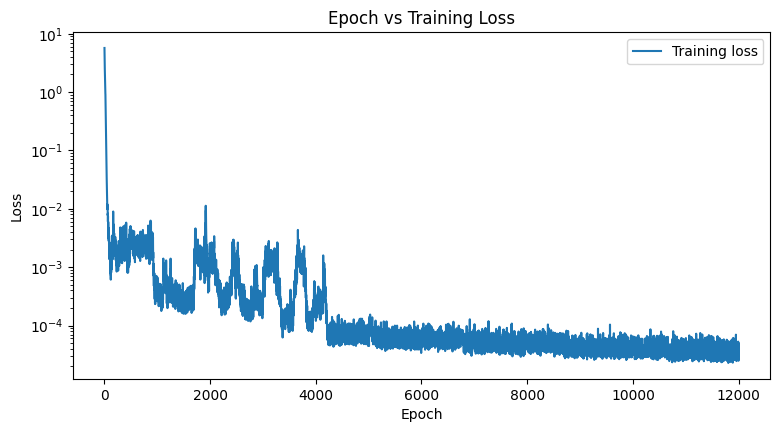

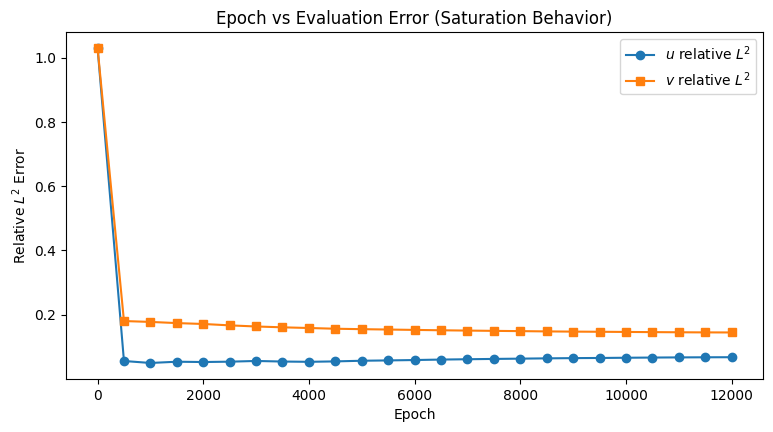

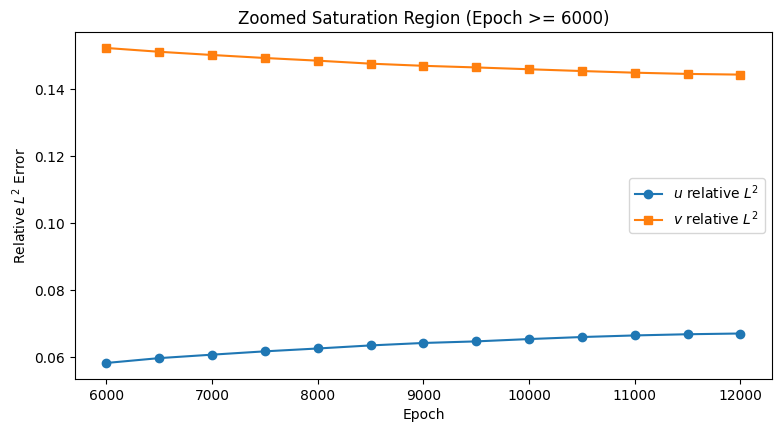

In [49]:
plot_saturation(history_sep, eval_history_sep, start_epoch_for_zoom=6000)

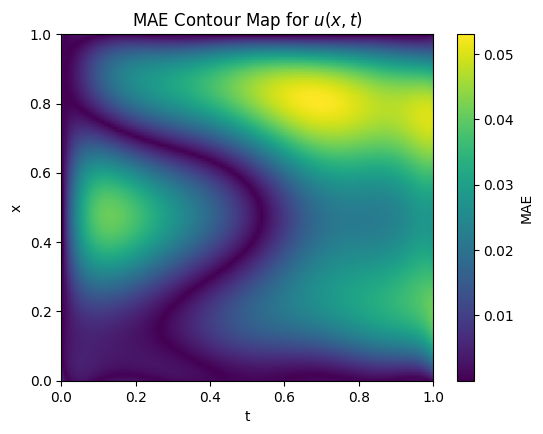

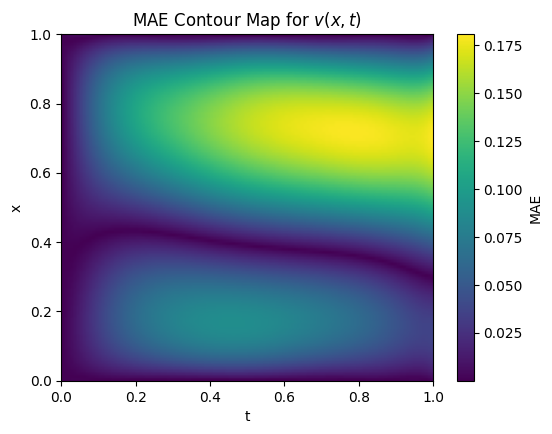

In [50]:
plot_mae_contours(final_sep_eval)